In [1]:
# --- Cell 0: Setup project path so analysis_utils is recognized ---

import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT added to sys.path:", PROJECT_ROOT)


PROJECT_ROOT added to sys.path: /Users/acastano/Desktop/crispr_carT_AI_analysis


In [2]:
# --- Cell 1: Imports & configuration ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_utils.config_utils import (
    PROCESSED_DIR,
    RESULTS_DIR,
    ensure_dirs,
)
from analysis_utils.umap_utils import compute_sample_umap, save_sample_umap

# Define UMAP results directory
UMAP_RESULTS_DIR = RESULTS_DIR / "umap"
ensure_dirs(UMAP_RESULTS_DIR)

PROCESSED_DIR, RESULTS_DIR, UMAP_RESULTS_DIR


(PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap'))

In [3]:
# --- Cell 2: Load logCPM expression and metadata ---

expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")
metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

expr_logcpm.shape, metadata.shape


((60675, 60), (60, 6))

In [4]:
# --- Cell 3: Compute sample UMAP using helper ---

umap_df, umap_model = compute_sample_umap(
    expr_logcpm=expr_logcpm,
    metadata=metadata,
    metadata_cols=["hours", "guide", "donor"],  # attach these if present
    n_hvg=2000,
    n_neighbors=10,
    min_dist=0.3,
    metric="euclidean",
    random_state=42,  # deterministic
)

umap_df.head()


/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,hours,guide,donor
CART0077_RNAseq_NgsRun1_001,-6.985565,35.621605,0,SafeHarbor,CART0077_D1
CART0077_RNAseq_NgsRun1_002,-6.683891,35.560734,0,RHOG,CART0077_D1
CART0077_RNAseq_NgsRun1_003,-6.857250,36.042992,0,SafeHarbor,CART0077_D2
CART0077_RNAseq_NgsRun1_004,-7.174887,35.303055,0,RHOG,CART0077_D2
CART0077_RNAseq_NgsRun1_005,-7.375573,35.829922,0,SafeHarbor,CART0077_D3


In [5]:
# --- Cell 4: Save sample UMAP coordinates to results/umap/ ---

coords_path = save_sample_umap(
    umap_df=umap_df,
    out_dir=UMAP_RESULTS_DIR,
    base_name="sample_umap",
)
coords_path


PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap/sample_umap_coordinates.csv')

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap/sample_umap_by_hours.png')

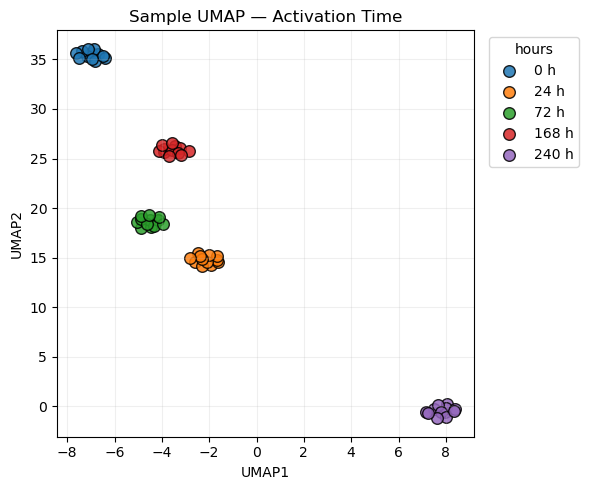

In [6]:
# --- Cell 5: UMAP colored by activation time (hours) ---

plt.figure(figsize=(6, 5))

for t in sorted(umap_df["hours"].dropna().unique()):
    m = umap_df["hours"] == t
    plt.scatter(
        umap_df.loc[m, "UMAP1"],
        umap_df.loc[m, "UMAP2"],
        s=70, alpha=0.85, edgecolor="k",
        label=f"{t} h",
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP — Activation Time")
plt.legend(title="hours", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()

umap_time_fig = UMAP_RESULTS_DIR / "sample_umap_by_hours.png"
plt.savefig(umap_time_fig, dpi=300, bbox_inches="tight")
umap_time_fig


PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap/sample_umap_by_guide.png')

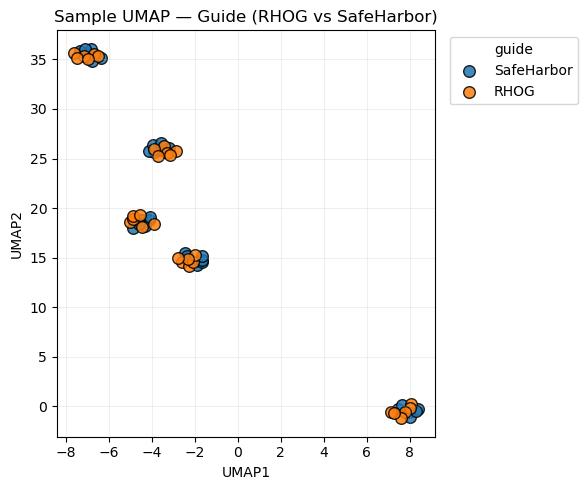

In [7]:
# --- Cell 6: UMAP colored by guide (perturbation) ---

plt.figure(figsize=(6, 5))

for g in umap_df["guide"].dropna().unique():
    m = umap_df["guide"] == g
    plt.scatter(
        umap_df.loc[m, "UMAP1"],
        umap_df.loc[m, "UMAP2"],
        s=70, alpha=0.85, edgecolor="k",
        label=str(g),
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP — Guide (RHOG vs SafeHarbor)")
plt.legend(title="guide", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()

umap_guide_fig = UMAP_RESULTS_DIR / "sample_umap_by_guide.png"
plt.savefig(umap_guide_fig, dpi=300, bbox_inches="tight")
umap_guide_fig


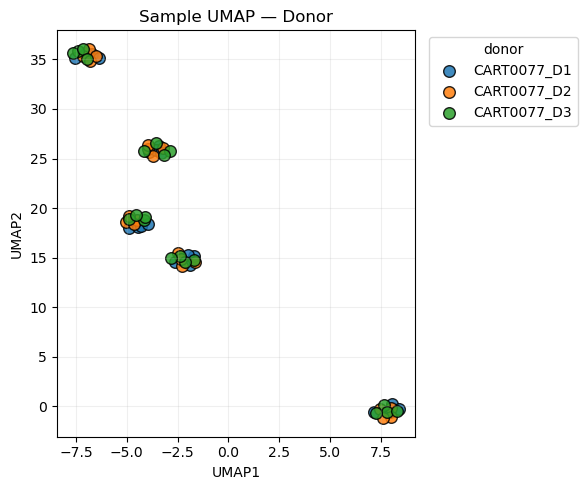

In [8]:
# --- Cell 7: UMAP colored by donor (if available) ---

if "donor" in umap_df.columns:
    plt.figure(figsize=(6, 5))

    for d in umap_df["donor"].dropna().unique():
        m = umap_df["donor"] == d
        plt.scatter(
            umap_df.loc[m, "UMAP1"],
            umap_df.loc[m, "UMAP2"],
            s=70, alpha=0.85, edgecolor="k",
            label=str(d),
        )

    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Sample UMAP — Donor")
    plt.legend(title="donor", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.2)
    plt.tight_layout()

    umap_donor_fig = UMAP_RESULTS_DIR / "sample_umap_by_donor.png"
    plt.savefig(umap_donor_fig, dpi=300, bbox_inches="tight")
    umap_donor_fig
else:
    print("No 'donor' column in metadata; skipping donor-colored UMAP.")


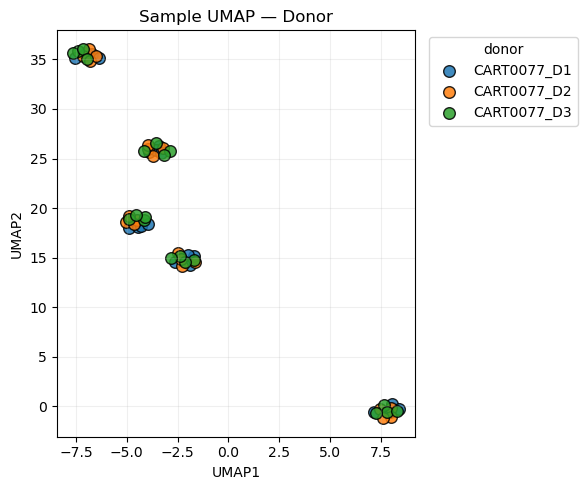

In [9]:
# --- Cell 8: UMAP colored by donor ---

if "donor" in umap_df.columns:
    plt.figure(figsize=(6, 5))

    for d in umap_df["donor"].dropna().unique():
        mask = umap_df["donor"] == d
        plt.scatter(
            umap_df.loc[mask, "UMAP1"],
            umap_df.loc[mask, "UMAP2"],
            s=70, alpha=0.85, edgecolor="k",
            label=str(d),
        )

    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Sample UMAP — Donor")
    plt.legend(title="donor", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.2)
    plt.tight_layout()

    umap_donor_fig = UMAP_RESULTS_DIR / "sample_umap_by_donor.png"
    plt.savefig(umap_donor_fig, dpi=300, bbox_inches="tight")
    umap_donor_fig
else:
    print("No 'donor' column in metadata; skipping donor-colored UMAP.")


In [10]:
UMAP_RESULTS_DIR = RESULTS_DIR / "umap"
ensure_dirs(UMAP_RESULTS_DIR)
umap_df.to_csv(UMAP_RESULTS_DIR / "sample_umap_coordinates.csv")


In [11]:
###wrap in a mini “run all” function
#At the bottom of A02, you can add:
def run_sample_umap_pipeline():
    expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")
    metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

    umap_df, umap_model = compute_sample_umap(
        expr_logcpm=expr_logcpm,
        metadata=metadata,
        metadata_cols=["hours", "guide", "donor"],
        n_hvg=2000,
        n_neighbors=10,
        min_dist=0.3,
        metric="euclidean",
        random_state=42,
    )

    coords_path = save_sample_umap(
        umap_df=umap_df,
        out_dir=UMAP_RESULTS_DIR,
        base_name="sample_umap",
    )

    print("Saved coordinates to:", coords_path)
    return umap_df, umap_model


In [12]:
umap_df, umap_model = run_sample_umap_pipeline()
umap_df.head()


Saved coordinates to: /Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap/sample_umap_coordinates.csv


/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,hours,guide,donor
CART0077_RNAseq_NgsRun1_001,-6.985565,35.621605,0,SafeHarbor,CART0077_D1
CART0077_RNAseq_NgsRun1_002,-6.683891,35.560734,0,RHOG,CART0077_D1
CART0077_RNAseq_NgsRun1_003,-6.857250,36.042992,0,SafeHarbor,CART0077_D2
CART0077_RNAseq_NgsRun1_004,-7.174887,35.303055,0,RHOG,CART0077_D2
CART0077_RNAseq_NgsRun1_005,-7.375573,35.829922,0,SafeHarbor,CART0077_D3


In [13]:
from pathlib import Path
import pandas as pd

# If you already have these from earlier cells, skip loading
# (otherwise load from disk)
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()
RESULTS_UMAP = PROJECT_ROOT / "results" / "umap"

# Expect these already exist from your A02 workflow
umap_df = pd.read_csv(RESULTS_UMAP / "sample_umap_coordinates.csv", index_col=0)
metadata = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "metadata_samples.csv", index_col=0)

# Make sure indices align
umap_df.index = umap_df.index.astype(str)
metadata.index = metadata.index.astype(str)
meta_umap = metadata.join(umap_df, how="inner")

# --- output dir for manuscript figures ---
OUTDIR = PROJECT_ROOT / "figures" / "fig2_activation_trajectories"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Use your existing plotting utilities if you have them.
# If you DON'T have them, this block will still work with a small inline plotter.

import matplotlib.pyplot as plt

def save_umap(meta_umap, color_col, outpath, title):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(
        meta_umap["UMAP1"], meta_umap["UMAP2"],
        c=meta_umap[color_col] if pd.api.types.is_numeric_dtype(meta_umap[color_col]) else None,
        s=55, alpha=0.85
    )

    # If categorical, plot by groups
    if not pd.api.types.is_numeric_dtype(meta_umap[color_col]):
        ax.clear()
        for k, dfk in meta_umap.groupby(color_col):
            ax.scatter(dfk["UMAP1"], dfk["UMAP2"], s=55, alpha=0.85, label=str(k))
        ax.legend(frameon=True, loc="best", title=color_col)
    else:
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label(color_col)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return outpath

p1 = save_umap(meta_umap, "hours", OUTDIR / "Fig2D3_sample_umap_by_hours.png", "Sample UMAP colored by activation time (hours)")
p2 = save_umap(meta_umap, "guide", OUTDIR / "Fig2D3_sample_umap_by_guide.png", "Sample UMAP colored by guide (SafeHarbor vs RHOG)")
p3 = save_umap(meta_umap, "donor", OUTDIR / "Fig2D3_sample_umap_by_donor.png", "Sample UMAP colored by donor")

print("Saved:", p1)
print("Saved:", p2)
print("Saved:", p3)

ValueError: columns overlap but no suffix specified: Index(['hours', 'guide', 'donor'], dtype='object')